# Model Evaluation and Refinement

## Mục tiêu

Sau khi hoàn thành lab này, bạn có thể:

-   Đánh giá và cải tiến các mô hình dự đoán

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Trong lab này, học viên có thể sử dụng dữ liệu đã được làm sạch từ lab 6&7 để phục vụ cho việc phát triển, đánh giá và cải tiến các mô hình dự đoán:

In [2]:
# Import clean data 
path = 'L11_datasets/clean_df.csv'
df = pd.read_csv(path)
df.head()

,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,5000.0,21,8.703704,13495.0,11.190476,Low,0,1,True,False
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,5000.0,21,8.703704,16500.0,11.190476,Low,0,1,True,False
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,5000.0,19,9.038462,16500.0,12.368421,Medium,0,1,True,False
3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,5500.0,24,7.833333,13950.0,9.791667,Low,0,1,True,False
4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,5500.0,18,10.681818,17450.0,13.055556,Low,0,1,True,False


Đầu tiên, chỉ lấy những dữ liệu dạng số

In [3]:
df=df._get_numeric_data()
df.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,horsepower,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,88.6,0.811148,0.890278,0.816054,2548,130,3.47,2.68,...,111,5000.0,21,8.703704,13495.0,11.190476,0,1,True,False
1,3,122,88.6,0.811148,0.890278,0.816054,2548,130,3.47,2.68,...,111,5000.0,21,8.703704,16500.0,11.190476,0,1,True,False
2,1,122,94.5,0.822681,0.909722,0.876254,2823,152,2.68,3.47,...,154,5000.0,19,9.038462,16500.0,12.368421,0,1,True,False
3,2,164,99.8,0.848630,0.919444,0.908027,2337,109,3.19,3.40,...,102,5500.0,24,7.833333,13950.0,9.791667,0,1,True,False
4,2,164,99.4,0.848630,0.922222,0.908027,2824,136,3.19,3.40,...,115,5500.0,18,10.681818,17450.0,13.055556,0,1,True,False


Cài đặt và import thư viện ipywidgets để trực quan hoá dữ liệu


In [4]:
%%capture
! pip install ipywidgets

In [5]:
try:
    from ipywidgets import interact, interactive, fixed, interact_manual
except ImportError:
    def interact(*args, **kwargs): return lambda f: f
    def interactive(*args, **kwargs): return lambda f: f
    def fixed(x): return x
    def interact_manual(*args, **kwargs): return lambda f: f


<h2>Tạo các customize function để trực quan hoá dữ liệu</h2>


In [6]:
def DistributionPlot(RedFunction, BlueFunction, RedName, BlueName, Title):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))

    ax1 = sns.distplot(RedFunction, hist=False, color="r", label=RedName)
    ax2 = sns.distplot(BlueFunction, hist=False, color="b", label=BlueName, ax=ax1)

    plt.title(Title)
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')
    plt.legend()
    plt.show()
    plt.close()

In [7]:
def PollyPlot(xtrain, xtest, y_train, y_test, lr,poly_transform):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))
    
    
    #training data 
    #testing data 
    # lr:  linear regression object 
    #poly_transform:  polynomial transformation object 
 
    xmax=max([xtrain.values.max(), xtest.values.max()])

    xmin=min([xtrain.values.min(), xtest.values.min()])

    x=np.arange(xmin, xmax, 0.1)


    plt.plot(xtrain, y_train, 'ro', label='Training Data')
    plt.plot(xtest, y_test, 'go', label='Test Data')
    plt.plot(x, lr.predict(poly_transform.fit_transform(x.reshape(-1, 1))), label='Predicted Function')
    plt.ylim([-10000, 60000])
    plt.ylabel('Price')
    plt.legend()

<h1 id="ref1">Phần 1: Training and Testing</h1>

<p>Một bước quan trọng trong quá trình thử nghiệm mô hình là bước chia dữ liệu thành dữ liệu huấn luyện (training data) và dữ liệu thử nghiệm (testing data). Chúng ta sẽ đặt dữ liệu mục tiêu <b>price</b> trong một dataframe riêng biệt <b>y</b>:</p>


In [8]:
y_data = df['price']

Loại bỏ cột `price` trong tập dữ liệu x_data


In [9]:
x_data=df.drop('price',axis=1)

Bây giờ, chúng ta chia ngẫu nhiên dữ liệu của mình thành dữ training data và testing data bằng cách sử dụng hàm <b>train_test_split</b>.

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1)

print("Số lượng mẫu testing data :", x_test.shape[0])
print("Số lượng mẫu training data :",x_train.shape[0])


Số lượng mẫu testing data : 21
Số lượng mẫu training data : 180


Tham số <b>test_size</b> là tỷ lệ phần trăm dữ liệu được chia thành dữ liệu testing data. Ở trên, testing data chiếm 10% trên tổng số dữ liệu.

### Bài tập 1

<b><b>Sử dụng hàm `train_test_split` để chia bộ dữ liệu thành 2 tập training & testing set, trong đó testing set chiếm 40% bộ dữ liệu. Đặt tham số random_state=0. Kết qủa của hàm được gán thành các biến sau đây:  "x_train_1" , "x_test_1", "y_train_1" và "y_test_1"</b></b>


In [11]:
# Code của bạn ở đây

Import <b>LinearRegression</b> từ module <b>linear_model</b>.



In [12]:
from sklearn.linear_model import LinearRegression

Tạo một Linear Regression object:


In [13]:
lre=LinearRegression()

Huấn luyện mô hình sử dụng biến `horsepower`


In [14]:
lre.fit(x_train[['horsepower']], y_train)

LinearRegression()

Tính chỉ số R^2 trên tập training set:

In [15]:
lre.score(x_train[['horsepower']], y_train)

0.662028747521533

Tính chỉ số R^2 trên tập testing set:


In [16]:
lre.score(x_test[['horsepower']], y_test)

0.3635480624962414

Chúng ta có thể thấy chỉ số R^2 ở trên tập tesing set nhỏ hơn rất nhiều trên tập training set

### Bài tập 2

<b><b>Xây dựng mô hình dựa trên bộ dữ liệu "x_train_1" , "x_test_1", "y_train_1" và "y_test_1" vừa được tạo ở trên, tính toán giá trị R^2 trên tập dữ liệu </b></b>



In [17]:
#  Code của bạn ở đây

Đôi khi bạn không có đủ dữ liệu thử nghiệm mô hình (Ví dụ các bài toán trong xử lý hình ảnh y tế, việc thu thập dữ liệu là rất khó khăn và tốn kém chi phí); 

Một cách để tiếp cận giúp chúng ta giải quyết vấn đề này là sử dụng Cross-validation. 

<h2>Cross-validation Score</h2>
Cross validation là một phương pháp thống kê được sử dụng để ước lượng hiệu quả của các mô hình học máy trong trường hợp dữ liệu không được dồi dào.


Tham số quan trọng trong kỹ thuật này là k, đại diện cho số nhóm mà dữ liệu sẽ được chia ra. Vì lý do đó, nó được mang tên k-fold cross-validation. Khi giá trị của k được lựa chọn, người ta sử dụng trực tiếp giá trị đó trong tên của phương pháp đánh giá. Ví dụ với k=10, phương pháp sẽ mang tên 10-fold cross-validation.

Kỹ thuật này thường bao gồm các bước như sau:

- Xáo trộn dataset một cách ngẫu nhiên
- Chia dataset thành k nhóm
- Với mỗi nhóm:
    - Sử dụng nhóm hiện tại để đánh giá hiệu quả mô hình
    - Các nhóm còn lại được sử dụng để huấn luyện mô hình
    - Huấn luyện mô hình
    - Đánh giá và tổng hợp hiệu quả của mô hình dựa từ các số liệu đánh giá

import <b>cross_val_score</b> từ module <b>model_selection</b>.


In [18]:
from sklearn.model_selection import cross_val_score

Chúng ta truyền tham số vào object `cross_val_score` với biến dự đoán là `horsepower`, biến mục tiêu là `y_data` và  biến `cv = 4` là số nhóm dữ liệu cần chia.

In [19]:
Rcross = cross_val_score(lre, x_data[['horsepower']], y_data, cv=4)

Chỉ số đánh giá mặc định là R^2; mỗi phần tử trong mảng là giá trị R^2 trung bình trong từng fold dữ liệu:

In [20]:
Rcross

array([0.77465419, 0.51718424, 0.74814454, 0.04825398])

Chúng ta có thể tính toán được giá trị trung bình và độ lệnh chuẩn của chỉ số R^2:

In [21]:
print("Giá trị trung bình của R^2: ", Rcross.mean(), "và độ lệch chuẩn là: " , Rcross.std())

Giá trị trung bình của R^2:  0.5220592359225417 và độ lệch chuẩn là:  0.29130480666118413


### Bài tập 3

<b><b>Tính toán giá trị trung bình R^2 khi sử dụng 2-folds cross-validation với dữ liệu biến dự đoán là `horsepower`</b></b>



In [22]:
# Code của bạn ở đây

Bạn cũng có thể sử dụng hàm `cross_val_predict` để dự đoán kết quả.

Hàm chia dữ liệu thành số folds được chỉ định, sử dụng dữ liệu một fold để kiểm tra và dữ liệu còn lại được sử dụng để huấn luyện. Đầu tiên nhập hàm:

In [23]:
from sklearn.model_selection import cross_val_predict

Chúng ta truyền tham số vào object `cross_val_predict` với biến dự đoán là `horsepower`, biến mục tiêu là `y_data` và  biến `cv = 4` là số nhóm dữ liệu cần chia. Chúng ta có thể lấy được kết quả:


In [24]:
yhat = cross_val_predict(lre,x_data[['horsepower']], y_data,cv=4)
yhat[0:5]

array([14142.23793549, 14142.23793549, 20815.3029844 , 12745.549902  ,
       14762.9881726 ])

<h1 id="ref2">Phần 2: Overfitting, Underfitting và Model Selection</h1>

<p>Dữ liệu testing set đôi khi được coi là dữ liệu ngoại mẫu (Không nằm trong tập dữ liệu dùng để huấn luyện mô hình), là thước đo tốt về mức độ hoạt động của mô hình của bạn trong thực tế.

  </p>


Huấn luyện mô hình hồi quy đa biến sử dụng các biến <b>'horsepower'</b>, <b>'curb-weight'</b>, <b>'engine-size'</b> and <b>'highway-L/100km'</b> làm biến dự đoán.


In [25]:
lr = LinearRegression()
lr.fit(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-L/100km']], y_train)

LinearRegression()

Dự đoán kết quả dựa trên dữ liệu traning set

In [26]:
yhat_train = lr.predict(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-L/100km']])
yhat_train[0:5]

array([ 7625.80349764, 28447.913572  , 14843.22185221,  3855.72028472,
       34567.84349196])

Dự đoán kết quả dựa trên dữ liệu testing set

In [27]:
yhat_test = lr.predict(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-L/100km']])
yhat_test[0:5]

array([11043.92953392,  5844.12954446, 11258.50532848,  6886.86402714,
       15325.73021747])

Hãy thực hiện một số đánh giá mô hình bằng cách sử dụng training set và testing set một cách riêng biệt. 

Đầu tiên chúng ta cần phải import thư viện seaborn và matplotlibb để vẽ đồ thị.

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

Hãy kiểm tra sự phân bố của các giá trị dự đoán của tập dữ liệu huấn luyện.

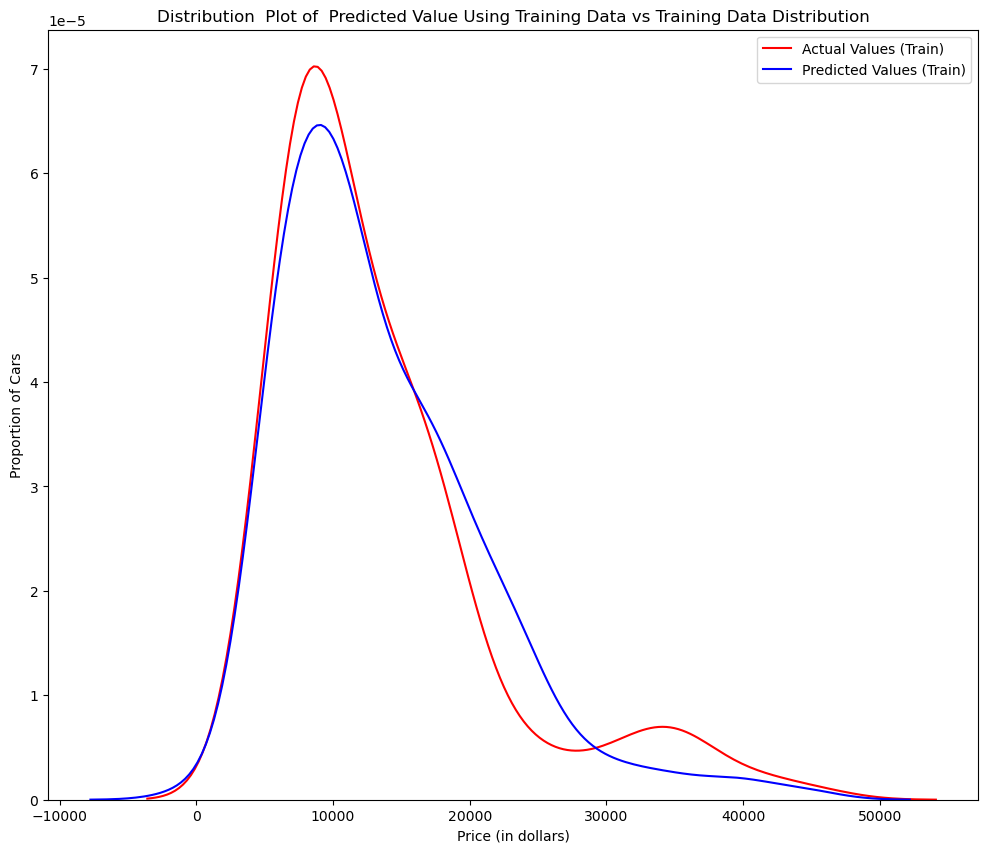

In [29]:
Title = 'Distribution  Plot of  Predicted Value Using Training Data vs Training Data Distribution'
DistributionPlot(y_train, yhat_train, "Actual Values (Train)", "Predicted Values (Train)", Title)

Hình 1: Đồ thị các giá trị dự đoán sử dụng dữ liệu huấn luyện so với dữ liệu huấn luyện.

Từ biểu đồ chúng ta có thể nhìn thấy mô hình được huấn luyện tốt ở trên tập dữ liệu training set. Vậy trên tập dữ liệu testing set, mô hình hoạt động như thế nào?


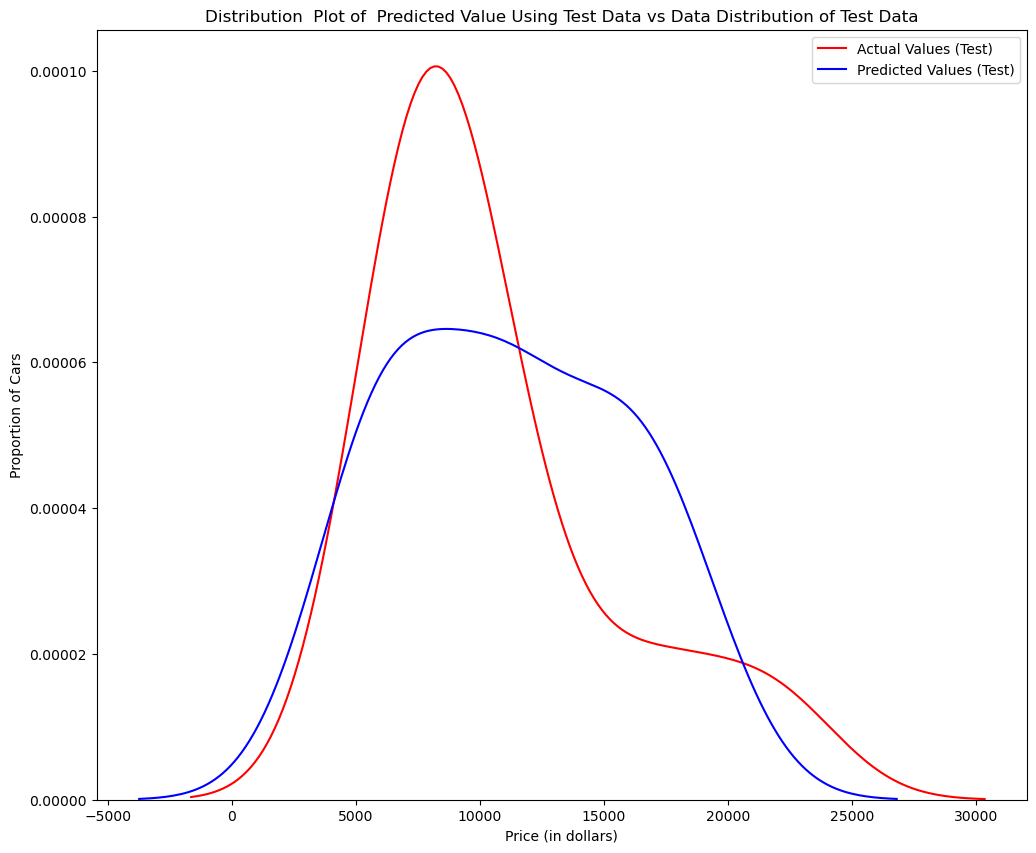

In [30]:
Title='Distribution  Plot of  Predicted Value Using Test Data vs Data Distribution of Test Data'
DistributionPlot(y_test,yhat_test,"Actual Values (Test)", "Predicted Values (Test)",Title)

Hình 2: Đồ thị giá trị dự đoán sử dụng dữ liệu thử nghiệm so với dữ liệu thử nghiệm.

Comparing Figure 1 and Figure 2; it is evident the distribution of the test data in Figure 1 is much better at fitting the data. 

So sánh giữa hình 1 và hình 2, chúng ta nhìn thấy kết quả dự đoán của mô hình dựa trên tập dữ liệu traning set (Hình 1) tốt hơn nhiều so với kết qủa của mô hình dựa trên tập dữ liệu testing set (Hình 2). Sự khác biệt trong Hình 2 thể hiện rõ ở các phạm vi từ 5000 đến 15000,là nơi hình dạng phân bố đặc biệt khác nhau.



In [31]:
from sklearn.preprocessing import PolynomialFeatures

<h4>Overfitting</h4>
<p>Overfitting là hiện tượng mô hình tìm được quá khớp với dữ liệu training. Việc quá khớp này có thể dẫn đến việc dự đoán nhầm nhiễu, và chất lượng mô hình không còn tốt trên dữ liệu test nữa. Dữ liệu test được giả sử là không được biết trước, và không được sử dụng để xây dựng các mô hình Machine Learning.
    
Về cơ bản, overfitting xảy ra khi mô hình quá phức tạp để mô phỏng training data. Điều này đặc biệt xảy ra khi lượng dữ liệu training quá nhỏ trong khi độ phức tạp của mô hình quá cao.
</p>



Bây giờ, hãy huấn luyện một mô hình đa thức bậc 5, và lấy 55% bộ dữ liệu cho training và phần còn lại cho testing.

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.45, random_state=0)

Chúng ta sẽ thực hiện phép biến đổi đa thức bậc 5 trên đặc tính <b>'horsepower'</b>.

In [33]:
pr = PolynomialFeatures(degree=5)
x_train_pr = pr.fit_transform(x_train[['horsepower']])
x_test_pr = pr.fit_transform(x_test[['horsepower']])
pr

PolynomialFeatures(degree=5)

Bây giờ, hãy tạo mô hình hồi quy tuyến tính "poly" và huấn luyện nó.

In [34]:
poly = LinearRegression()
poly.fit(x_train_pr, y_train)

LinearRegression()

Chúng ta có thể thấy kết quả đầu ra của mô hình bằng phương pháp `.predict()`, sau đó gán giá trị cho `yhat`.

In [35]:
yhat = poly.predict(x_test_pr)
yhat[0:5]

array([ 6727.55154573,  7306.6838831 , 12213.7061876 , 18895.06623344,
       19996.87412402])

Hãy lấy năm giá trị dự đoán đầu tiên và so sánh nó với các kết quả thực tế.

In [36]:
print("Predicted values:", yhat[0:4])
print("True values:", y_test[0:4].values)

Predicted values: [ 6727.55154573  7306.6838831  12213.7061876  18895.06623344]
True values: [ 6295. 10698. 13860. 13499.]


Chúng ta sẽ sử dụng hàm "PollyPlot" mà đã được tạo ở đầu bài thực hành để hiển thị dữ liệu huấn luyện, dữ liệu kiểm tra và hàm dự đoán.

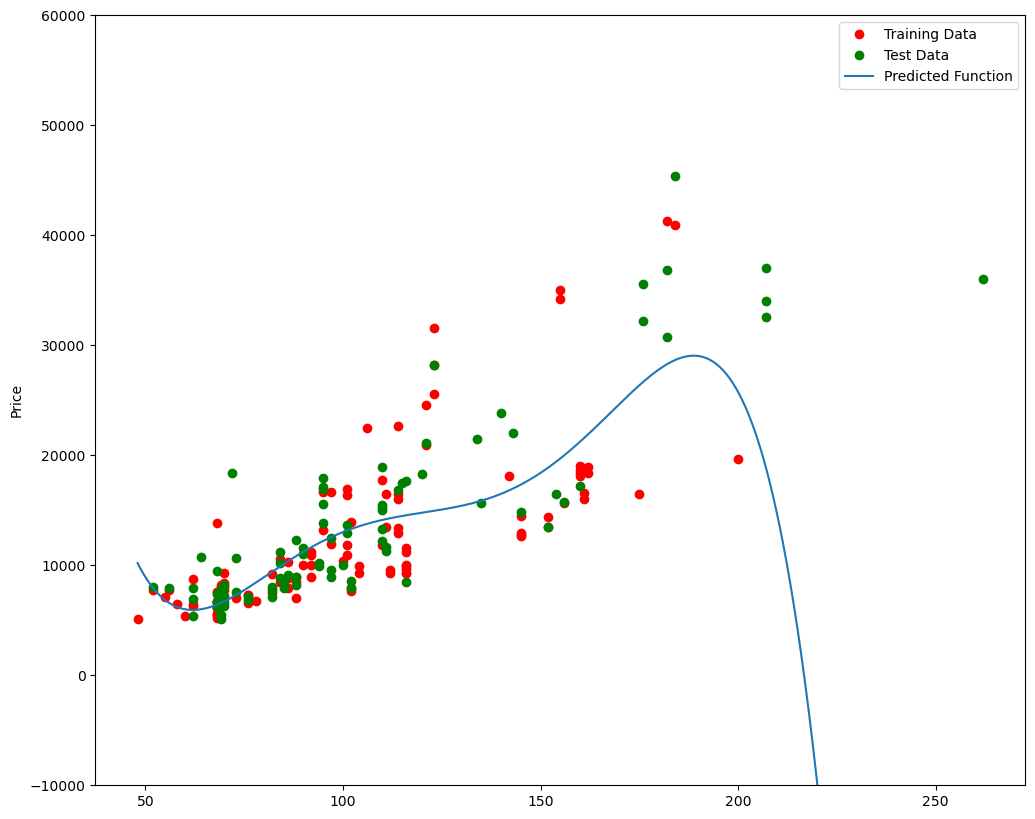

In [37]:
PollyPlot(x_train[['horsepower']], x_test[['horsepower']], y_train, y_test, poly,pr)

Hình 4 cho thấy mô hình hồi quy đa thức, các chấm màu đỏ biểu thị dữ liệu huấn luyện, các chấm màu xanh lá cây biểu thị dữ liệu thử nghiệm và đường màu xanh lam biểu thị mô hình dự đoán.

Tính chỉ số R^2 cho tập dữ liệu training set:


In [38]:
poly.score(x_train_pr, y_train)

0.5568527854124077

Tính chỉ số R^2 cho tập dữ liệu testing set:


In [39]:
poly.score(x_test_pr, y_test)

-29.815329237252364

Kết qủa cho thấy R^2 cho dữ liệu huấn luyện là 0,5568 trong khi R^2 trên dữ liệu thử nghiệm là -29,82. R^2 càng thấp thì mô hình càng tệ, R^2 âm là dấu hiệu của việc mô hình bị overfitting.

Hãy xem R^2 thay đổi như thế nào trên dữ liệu thử nghiệm đối với các đa thức bậc khác nhau và vẽ biểu đồ kết quả:

Text(3, 0.75, 'Maximum R^2 ')

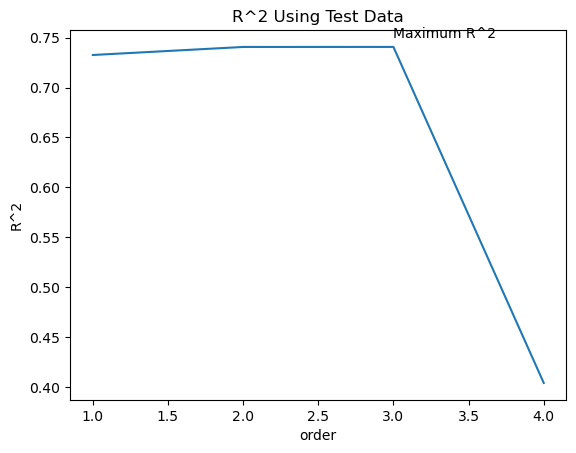

In [40]:
Rsqu_test = []

order = [1, 2, 3, 4]
for n in order:
    pr = PolynomialFeatures(degree=n)
    
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    
    x_test_pr = pr.fit_transform(x_test[['horsepower']])    
    
    lr.fit(x_train_pr, y_train)
    
    Rsqu_test.append(lr.score(x_test_pr, y_test))

plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
plt.text(3, 0.75, 'Maximum R^2 ')  

Biểu đồ cho thấy R^2 tăng dần cho đến khi sử dụng đa thức bậc ba. Sau đó R^2 giảm đáng kể ở mức 4.

Hàm sau đây được sử dụng cho phần tiếp theo, chúng ta cần chạy đoạn code này để khai báo nó

In [41]:
def f(order, test_data):
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=test_data, random_state=0)
    pr = PolynomialFeatures(degree=order)
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    x_test_pr = pr.fit_transform(x_test[['horsepower']])
    poly = LinearRegression()
    poly.fit(x_train_pr,y_train)
    PollyPlot(x_train[['horsepower']], x_test[['horsepower']], y_train,y_test, poly, pr)

Hàm sau đây cho phép bạn thử nghiệm các bậc đa thức khác nhau và lượng dữ liệu khác nhau.

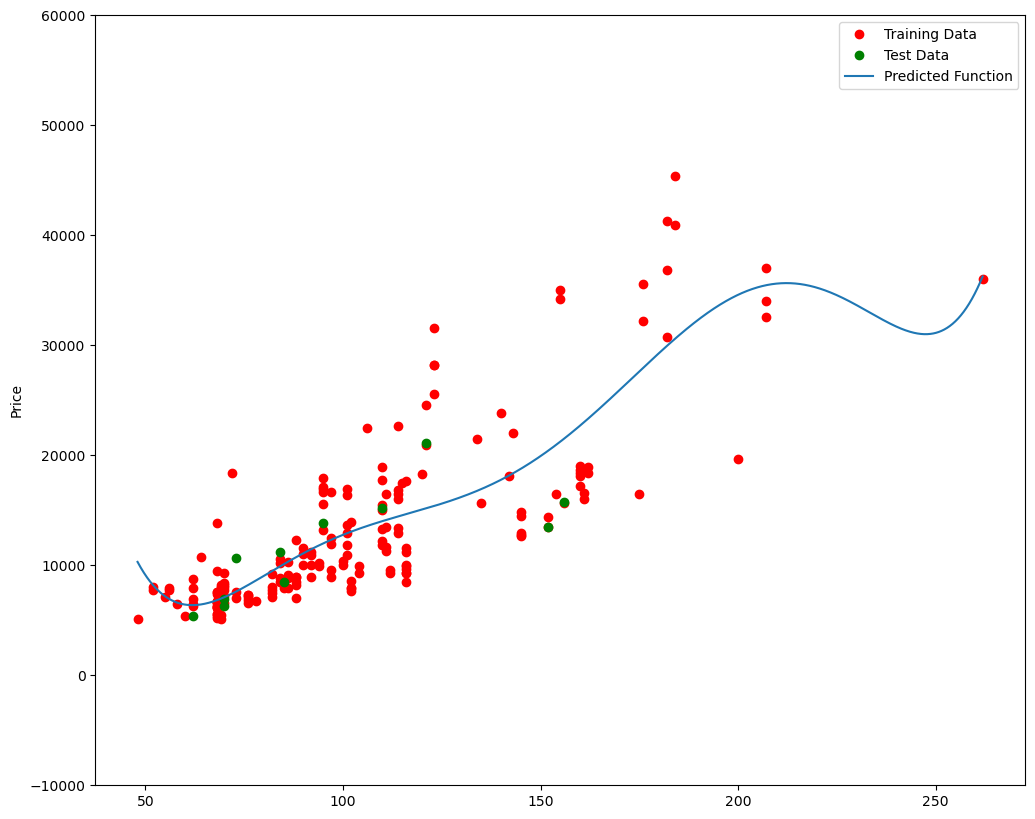

In [42]:
f(6, 0.05)

### Bài tập 4a

<b><b>Chúng ta có thể thực hiện các phép biến đổi đa thức với nhiều biến dự đoán. Tạo một "PolynomialFeatures" object bậc 2 có tên là `pr1` </b></b>





In [43]:
# Code của bạn ở đây

### Bài tập 4b

<b><b>Thực hiện phép biến đổi đa thức với các biến dự đoán: 'horsepower', 'curb-weight', 'engine-size' và 'highway-L/100km' cho tập training và testing set </b></b>

Hint: sử dụng phương thức "fit_transform" 



In [44]:
# Code của bạn ở đây

<!-- The answer is below:

x_train_pr1=pr.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
x_test_pr1=pr.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])

-->


### Bài tập 4c

<b><b>Kích thước của biến mục tiêu mới sau khi biến đổi? </b></b>

Hint: sử dụng phương thức "shape" 



In [45]:
# Code của bạn ở đây

### Bài tập 4d

<b><b>Tạo một linear regression object "poly1", huấn luyện nó với bộ biến mục tiêu vừa được biến đổi </b></b>

In [46]:
# Code của bạn ở đây


### Bài tập 4e

<b><b>Sử dụng phương pháp "predict" để dự đoán kết quả đầu ra trên các đặc trưng đa thức (biến mục tiêu vừa được biến đổi), sau đó sử dụng hàm "DistributionPlot" để hiển thị phân bố của kết quả dự đoán so với dữ liệu thử nghiệm?</b></b>

In [47]:
# Code của bạn ở đây

Nhìn vào biểu đồ chúng ta có thể thấy: Giá trị dự đoán cao hơn giá trị thực tế đối với những chiếc ô tô có mức giá trong khoảng 10.000 USD, ngược lại, giá dự đoán thấp hơn giá thành trong khoảng 30.000 USD đến 40.000 USD. Vì vậy, mô hình không chính xác trong các phạm vi này

<h2 id="ref3">Phần 3: Ridge regression</h2> 


Trong phần này, chúng ta sẽ xem xét Hồi quy Ridge, chúng ta sẽ thấy tham số alpha thay đổi mô hình như thế nào. Chỉ cần lưu ý ở đây dữ liệu thử nghiệm của chúng ta sẽ được sử dụng làm dữ liệu xác thực.

Hãy thực hiện phép biến đổi đa thức bậc hai trên dữ liệu

In [48]:
pr=PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-L/100km','normalized-losses','symboling']])
x_test_pr=pr.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-L/100km','normalized-losses','symboling']])

Import  <b>Ridge</b>  từ module <b>linear models</b>.


In [49]:
from sklearn.linear_model import Ridge

Hãy tạo một đối tượng hồi quy Ridge, đặt tham số chính quy thành 0,1

In [50]:
RigeModel=Ridge(alpha=0.1)

Giống như hồi quy thông thường, bạn có thể fit mô hình bằng phương pháp <b>fit</b>.

In [51]:
RigeModel.fit(x_train_pr, y_train)

Ridge(alpha=0.1)

Tương tự, bạn có thể dự đoán giá xe bằng mô hình này:

In [52]:
yhat = RigeModel.predict(x_test_pr)

Hãy so sánh năm mẫu dự đoán đầu tiên với tập thử nghiệm

In [53]:
print('predicted:', yhat[0:4])
print('test set :', y_test[0:4].values)

predicted: [ 5547.45797502 10300.41178392 21672.72800189 19342.30072745]
test set : [ 6295. 10698. 13860. 13499.]


Chúng ta cần chọn giá trị Alpha hợp lý để tăng độ chính xác trên tập dữ liệu testing set, ví dụ: chúng ta có thể sử dụng vòng lặp for.

In [54]:
Rsqu_test = []
Rsqu_train = []
dummy1 = []
Alpha = 10 * np.array(range(0,1000))
for alpha in Alpha:
    RigeModel = Ridge(alpha=alpha) 
    RigeModel.fit(x_train_pr, y_train)
    Rsqu_test.append(RigeModel.score(x_test_pr, y_test))
    Rsqu_train.append(RigeModel.score(x_train_pr, y_train))

Chúng ta có thể trực quan giá trị của R^2 cho các Alpha khác nhau

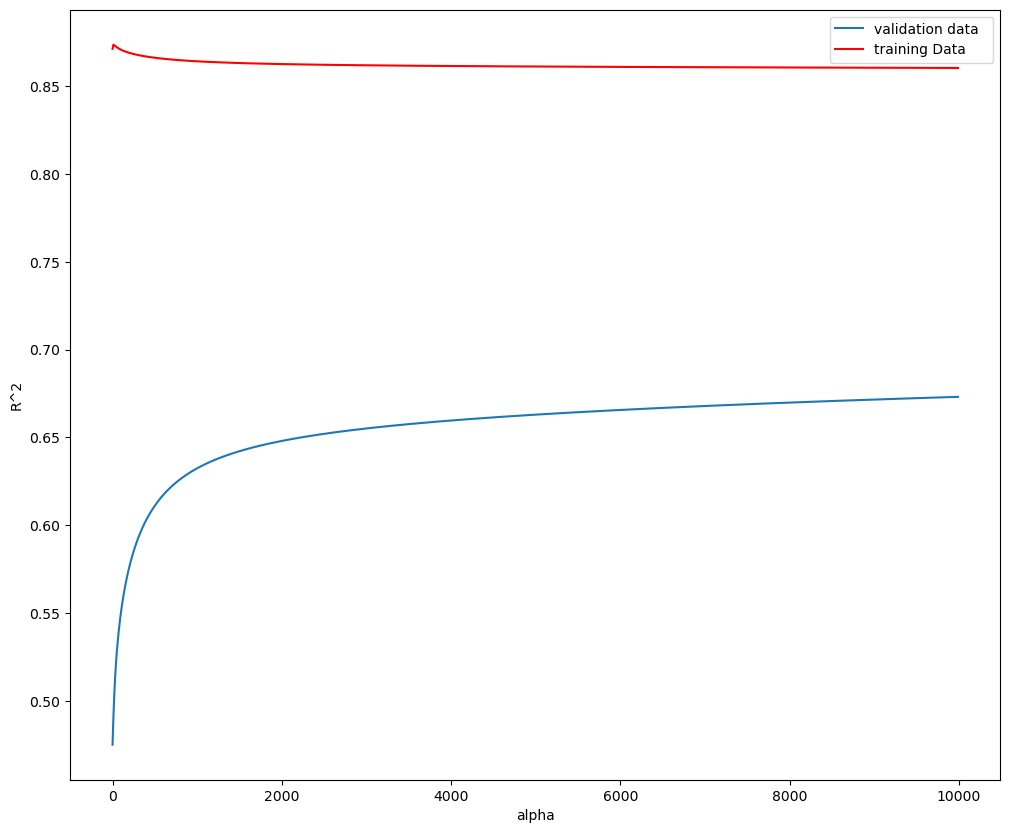

In [55]:
width = 12
height = 10
plt.figure(figsize=(width, height))

plt.plot(Alpha,Rsqu_test, label='validation data  ')
plt.plot(Alpha,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()

**Hình 6**:Đường màu xanh biểu thị R^2 của dữ liệu testing set và đường màu đỏ biểu thị R^2 của dữ liệu trainingset. Trục x biểu thị các giá trị khác nhau của Alpha.

Dường màu đỏ biểu thị R^2 của dữ liệu training set.  Khi Alpha tăng thì R^2 giảm. Do đó, khi Alpha tăng, mô hình hoạt động kém hơn trên dữ liệu huấn luyện.

Đường màu xanh biểu thị R^2 trên dữ testing set. Khi giá trị của Alpha tăng thì R^2 cũng tăng và hội tụ tại một điểm


### Bài tập 5

<b><b>Thực hiện hồi quy Ridge và tính toán R^2 bằng cách sử dụng các dữ liệu đã được biến đổi đa thức bậc hai , sử dụng dữ liệu training set" `x_train_pr` để huấn luyện mô hình và dữ liệu testing set: `x_test_pr` để kiểm tra mô hình. Tham số alpha phải được đặt thành 10. </b></b>

In [56]:
# Code của bạn ở đây

<h2 id="ref4">Phần 4: Grid Search</h2>


Thuật ngữ alpha là một siêu tham số (hyperparameter), sklearn có class <b>GridSearchCV</b> để làm cho quá trình tìm ra hyperparameter tốt nhất trở nên đơn giản hơn.


Import <b>GridSearchCV</b> từ module <b>model_selection</b>.


In [57]:
from sklearn.model_selection import GridSearchCV

Tạo một dict `parameters1` chứa các giá trị tham số:

In [58]:
parameters1= [{'alpha': [0.001,0.1,1, 10, 100, 1000, 10000, 100000, 100000]}]
parameters1

[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 100000]}]

Tạo 1 ridge object:


In [59]:
RR=Ridge()
RR

Ridge()

Tạo một ridge grid search object 


In [60]:
Grid1 = GridSearchCV(RR, parameters1,cv=4)

Huấn luyện mô hình

In [61]:
Grid1.fit(x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-L/100km']], y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000,
                                    100000]}])

Đối tượng tìm thấy các giá trị tham số tốt nhất trên dữ liệu testing set. Chúng ta có thể lấy tham số tốt nhất và gán nó cho biến BestRR như sau:

In [62]:
BestRR=Grid1.best_estimator_
BestRR

Ridge(alpha=10000)

Kiểm tra mô hình của mình trên dữ liệu thử nghiệm testing set

In [63]:
BestRR.score(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-L/100km']], y_test)

0.8411508430484372

### Thank you for completing this lab!